# Nipigon (Logan) sills ca. 1108 Ma paleomagnetic pole

## Geologic context

The Nipigon sills (long known as the Logan sills) are reversely magnetized mafic sills
and related intrusions emplaced into the Mesoproterozoic Sibley Group and older
Animikie and Archean rocks of the Nipigon Embayment and the Thunder Bay district on
the north shore of Lake Superior. They were intruded during the earliest magmatic
stage of the Midcontinent Rift, contemporaneous with the lower Osler Volcanic Group,
and are among the most widely sampled units of the "Keweenawan" reverse-polarity
interval. Sill thicknesses reach several hundred metres and the sills are subhorizontal
to gently dipping toward the rift axis.

## Paleomagnetic data

Earlier versions of this compilation carried the Lulea Working Group (2009) eight-unit
grand mean as reported in Evans et al. (2021), for which the underlying per-unit data
were not digitized. This entry instead recomputes the pole from a site-level compilation
of the published results (E. J. Iloranta, 2026), drawing on DuBois (1962), Robertson and
Fahrig (1971), Pesonen (1979), Middleton et al. (2004), Borradaile and Middleton (2006),
and the Thunder Intrusion result of Piispa et al. (in preparation). VGPs were recomputed
from the published site mean directions and site coordinates rather than adopted from the
original papers, and reverse-polarity VGPs are reported as the antipodal north pole.

Because many of the same sills were sampled by more than one study, and because
Middleton et al. (2004) list the same locality repeatedly under different demagnetization
treatments, the published results are averaged in two stages into independent cooling
units before the pole is computed. Two further same-sill correlations established from the
source publications are applied, and three that the publications do not resolve are
reported below as a sensitivity test. The construction of the site table, the merging
rules, and the exclusions are documented in
`../data/1108_Nipigon/contribution_build/build_nipigon_contribution.py`.

## Age

The Nipigon (Logan) sills cluster in age near 1105-1109 Ma. The Nipigon sills are dated
at 1108.2 +/- 0.9 Ma (zircon upper intercept, recalculated from the data of Davis and
Sutcliffe, 1985), and Bleeker et al. (2020) report new high-precision U-Pb dates of
1106.3 +/- 2.0 Ma for the main Logan Sill at Mount McKay and 1105.5 +/- 3.0 Ma for the
Inspiration sill. The pole is assigned an age of 1108 +/- 2 Ma. The older Heaman et al.
(2007) baddeleyite dates are imprecise and superseded and are not used here.


In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

`../data/1108_Nipigon/sites.txt` holds one row per independent cooling unit. Each row is
either a single published site mean or the Fisher mean of several determinations of the
same sill (the `description` field records which). The sills are intrusive and are treated
in geographic coordinates (`dir_tilt_correction = 0`), so the geographic frame is used
throughout. Results excluded from the pole are retained in the file with
`result_quality = 'b'` and are dropped on load.


In [2]:
units, _ = pt.load_magic_sites('../data/1108_Nipigon/sites.txt')
all_rows, _ = pt.load_magic_sites('../data/1108_Nipigon/sites.txt', drop_bad=False)

print(f'{len(units)} independent units entering the pole '
      f'({units["dir_n_samples"].sum()} samples)')
print(units['location'].value_counts().to_string())
print()
print('excluded and retained in the contribution:')
print(all_rows[all_rows['result_quality'] == 'b'][['site', 'description']].to_string(index=False))

37 independent units entering the pole (371 samples)
location
Nipigon Embayment    26
Thunder Bay-Logan    11

excluded and retained in the contribution:
   site                                                                                                                                                                                            description
    S11                                                                                                    EXCLUDED FROM POLE: flagged "Excluded!" in the source compilation (S11; Robertson and Fahrig, 1971)
    M13 EXCLUDED FROM POLE: normal-polarity counterpart of a reverse determination of the same Middleton et al. (2004) locality; interpreted as an incompletely removed overprint (M13; Middleton et al. 2004)
     M6  EXCLUDED FROM POLE: normal-polarity counterpart of a reverse determination of the same Middleton et al. (2004) locality; interpreted as an incompletely removed overprint (M6; Middleton et al. 2004)
  PL_ST           

The published results behind each unit, including the excluded ones and the exclusion
reason, are kept alongside the build script.


In [3]:
results = pd.read_csv('../data/1108_Nipigon/contribution_build/accepted_results.csv')
merged = results[results['accepted']].groupby('unit').filter(lambda g: len(g) > 1)
print('units built by merging more than one published determination:')
print(merged[['unit', 'site', 'Reference', 'dir_dec', 'dir_inc',
              'dir_alpha95', 'dir_n_samples']].to_string(index=False))

units built by merging more than one published determination:
          unit     site                  Reference    dir_dec    dir_inc  dir_alpha95  dir_n_samples
Red Rock North   N12-15               DuBois, 1962 133.658199 -72.045116     5.097454              8
Red Rock North  N29 BCT               DuBois, 1962 145.593997 -73.661092     5.730223              4
Red Rock North   N27-29               DuBois, 1962 113.167255 -86.253164     5.492538              2
        Quimet       S2 Robertson and Fahrig, 1971 116.000000 -64.000000     8.000000              5
 Colville Lake       S5 Robertson and Fahrig, 1971  53.000000 -69.000000     7.000000              7
 Colville Lake       S6 Robertson and Fahrig, 1971  53.000000 -75.000000    10.000000              5
Red Rock North      S13 Robertson and Fahrig, 1971 148.000000 -88.000000    26.000000              5
     Kama Hill      S14 Robertson and Fahrig, 1971  84.000000 -62.000000    14.000000              4
        Quimet      R42      

In [4]:
pt.plot_site_map(units, zoom_start=7)

## The Nipigon sills pole

The pole is the Fisher mean of the unit VGPs.


Plon: 220.3  Plat: 51.2
Number of directions in mean (n): 37
Angular radius of 95% confidence (A_95): 5.2
Precision parameter (k) estimate: 21.8


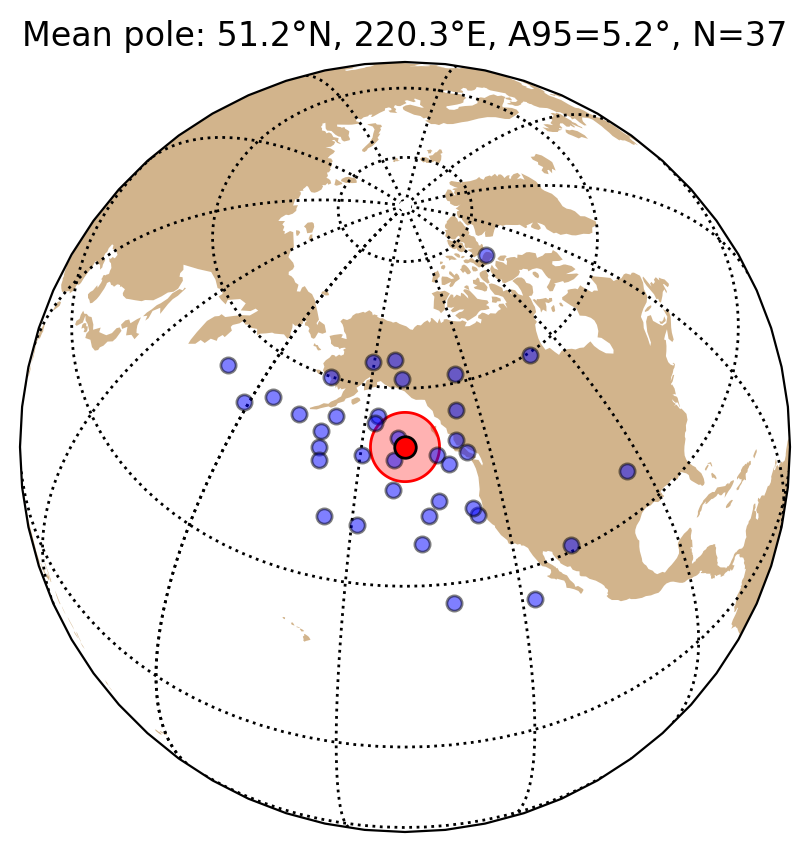

In [5]:
STUDY_LAT, STUDY_LON = units['lat'].mean(), units['lon'].mean()

vgp_block, pole_mean = pt.compute_mean_pole(units, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(5, 5))

Dec: 114.6  Inc: -71.8
Number of directions in mean (n): 37
Angular radius of 95% confidence (a_95): 3.2
Precision parameter (k) estimate: 56.5


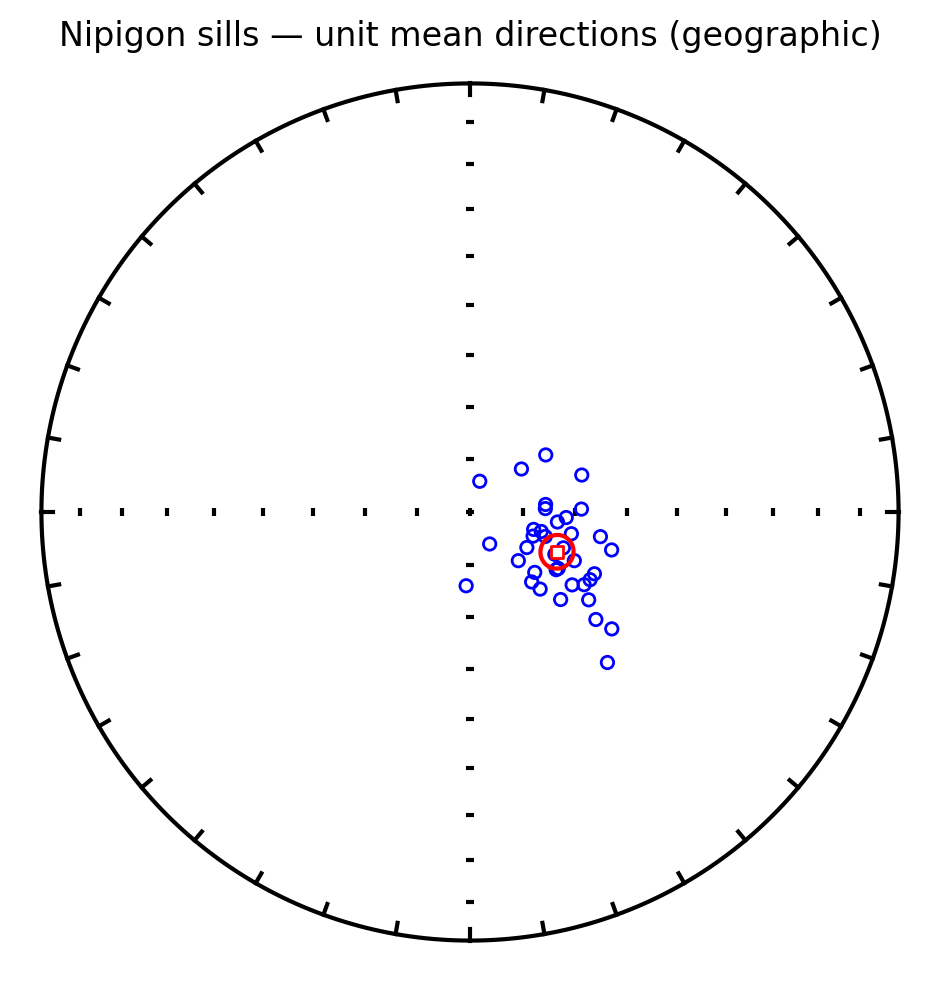

In [6]:
dir_block, dir_mean = pt.compute_mean_direction(units, unify_polarity=False)
ipmag.print_direction_mean(dir_mean)
ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], color='red', marker='s')
plt.title('Nipigon sills — unit mean directions (geographic)')
plt.show()

A_95 of 5.2 passes Deenen et al. (2011) criteria of being between 2.8 and 8.4 for this number of sites


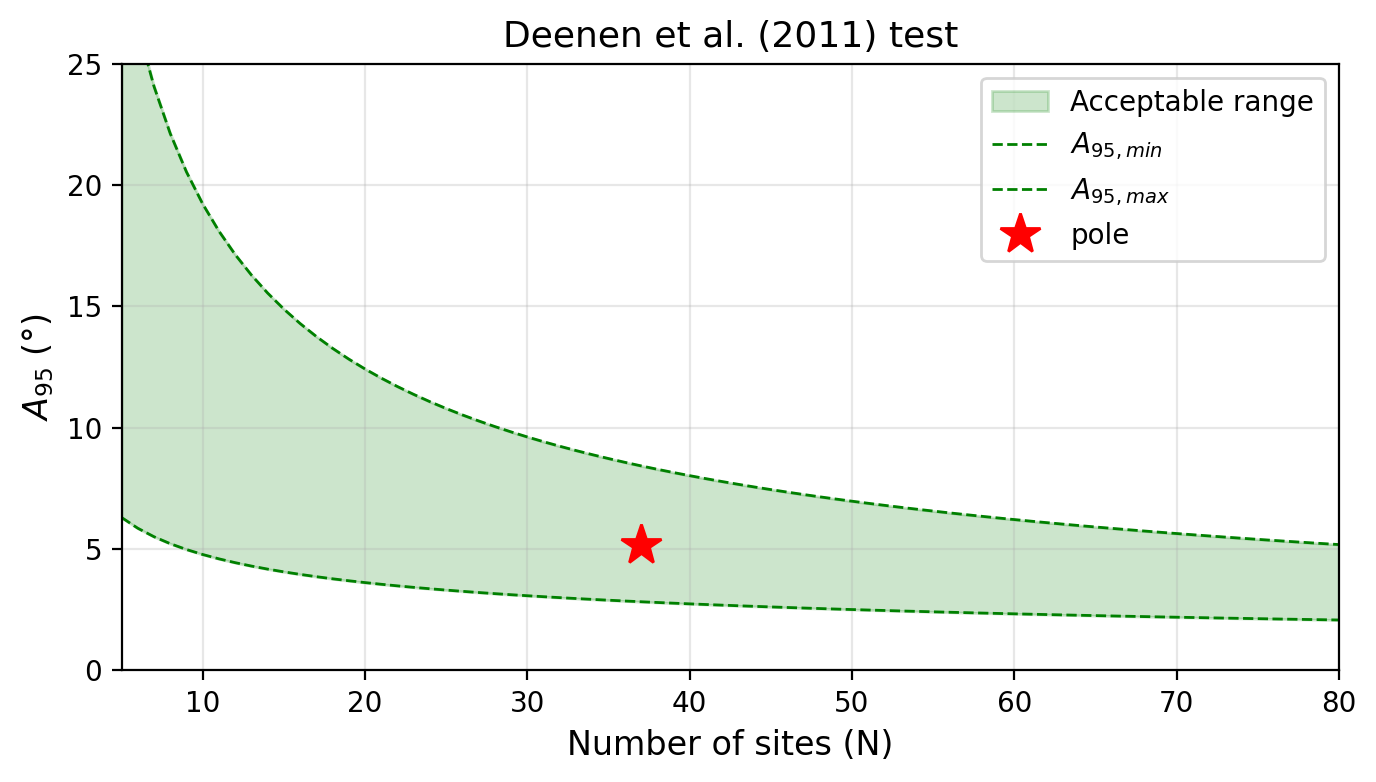

In [7]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
_ = pt.plot_Deenen_test(pole_mean)

{'Mode': 'Mode 1',
 'Dec': np.float64(219.93065812462902),
 'Inc': np.float64(51.208901097606656),
 'N': 37,
 'Mu': np.float64(0.889932674395008),
 'Mu_critical': 1.207,
 'Me': np.float64(0.8835863167978286),
 'Me_critical': 1.094,
 'Test_result': 'Consistent with Fisher distribution'}

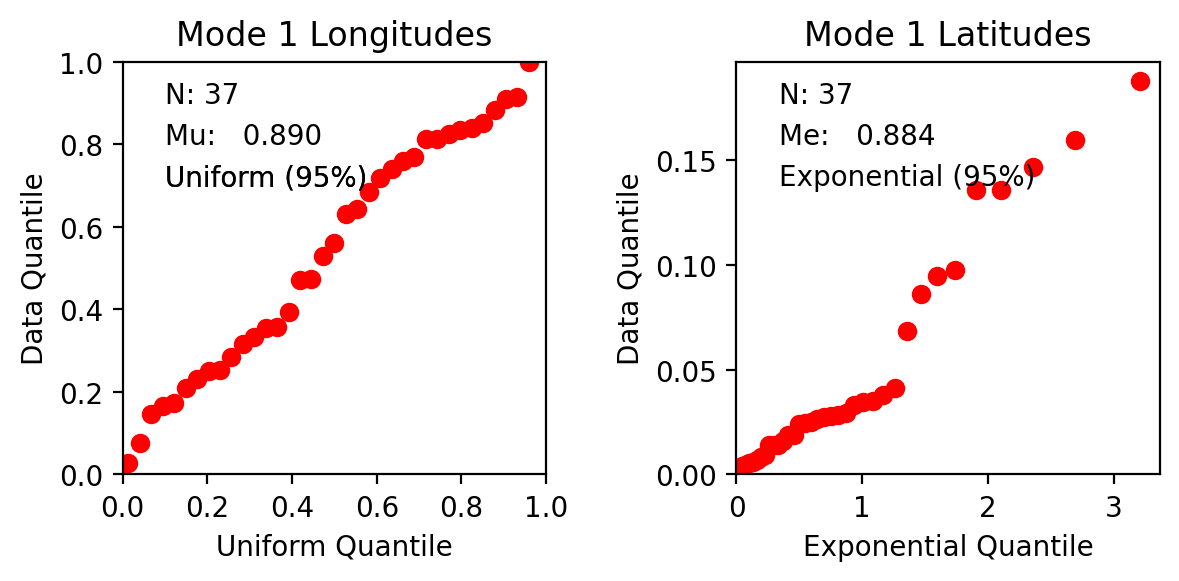

In [8]:
fishqq_result = pt.fishqq_vgps(units, unify_polarity=True)
fishqq_result

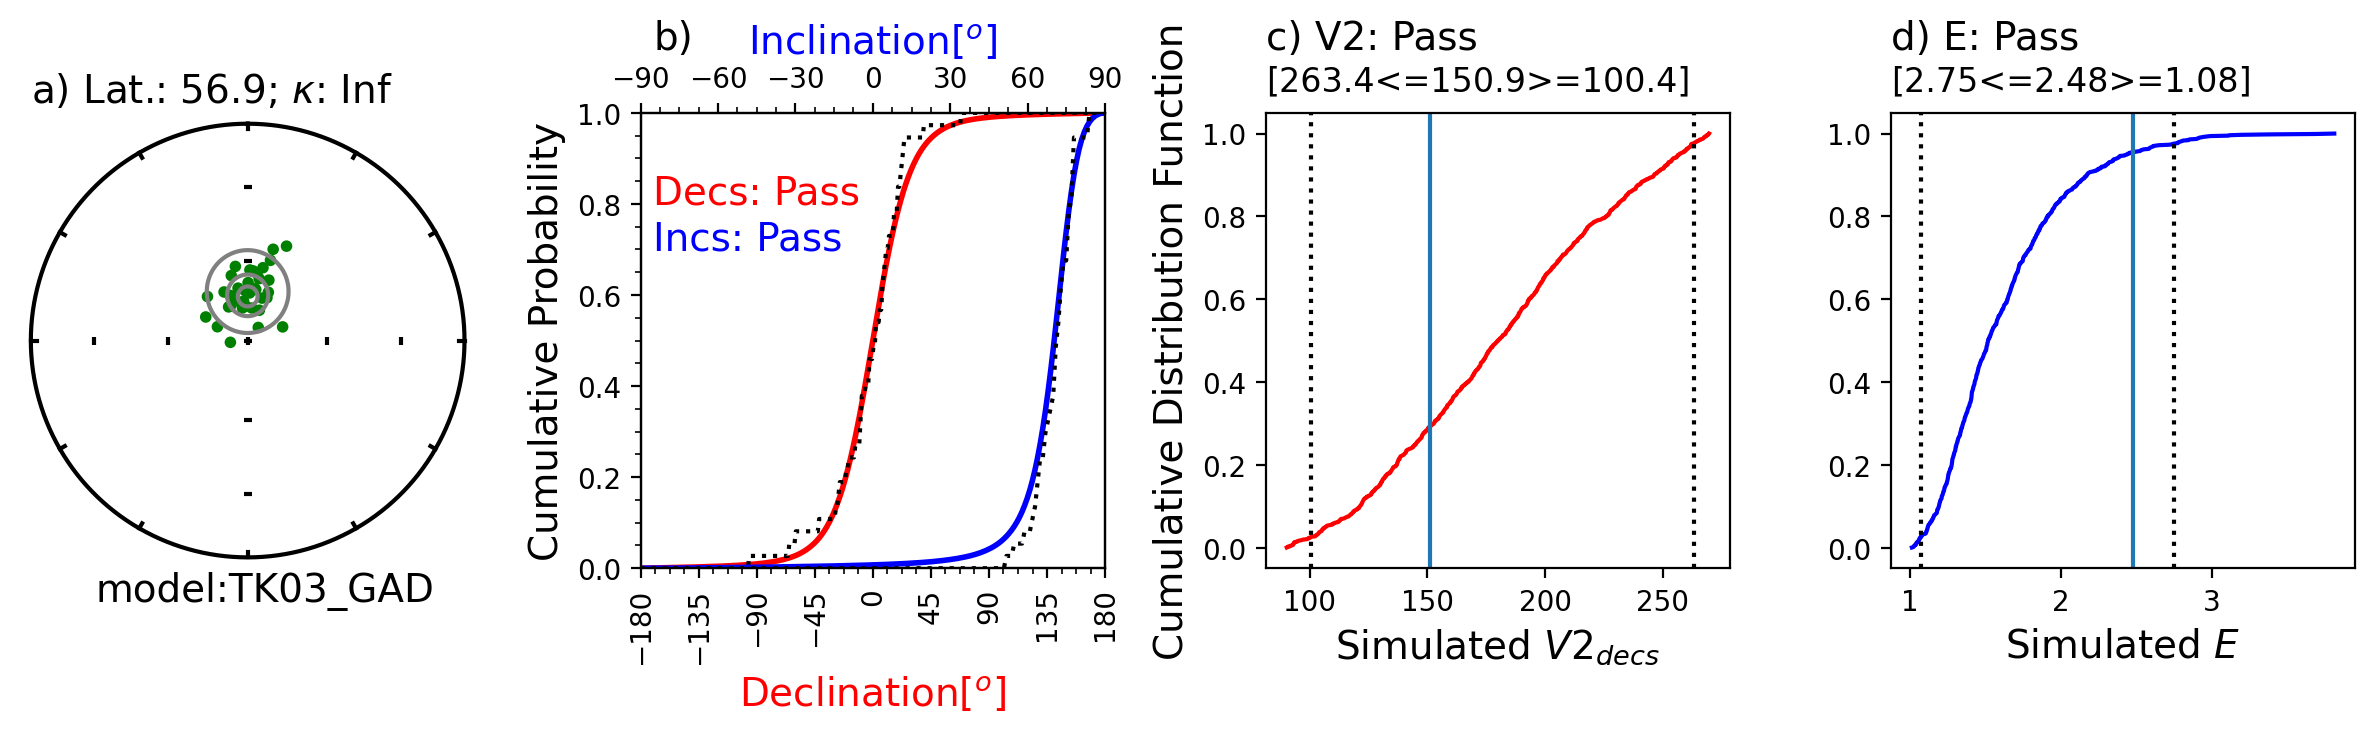

paleolatitude = 56.9°; elongation E = 2.48 (consistent with TK03.GAD)


In [9]:
svei_result = pt.svei_test_vgps(units, STUDY_LON, STUDY_LAT, model='TK03_GAD', plot=True)
print(f"paleolatitude = {svei_result['lat']:.1f}\u00b0; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

The VGP distribution is consistent with a Fisher distribution. The elongation is
higher than the TK03.GAD prediction, which is expected for a compilation of sills of
heterogeneous quality drawn from six studies over a ~200 km wide region rather than a
single stratigraphically controlled sequence; the elongation direction is not
interpreted here.


## Comparison between regions

The compiled sills fall into two geographic groups: those of the Nipigon Embayment
proper, and those of the Thunder Bay-Logan area to the southwest (including the Sibley
Peninsula and the Mount McKay sill). Both were emplaced during the same short-lived
magmatic episode, so the two sub-poles provide an internal consistency check.


In [10]:
region_results = {}
for region in ['Nipigon Embayment', 'Thunder Bay-Logan']:
    sub = units[units['location'] == region].reset_index(drop=True)
    _, p = pt.compute_mean_pole(sub, unify_polarity=True)
    _, d = pt.compute_mean_direction(sub, unify_polarity=False)
    region_results[region] = dict(sub=sub, pole=p, dir=d)
    print(f'{region:20s} N={p["n"]:3d}  plat={p["inc"]:5.1f}  plon={p["dec"]:6.1f}  '
          f'A95={p["alpha95"]:5.1f}  K={p["k"]:5.1f}')

Nipigon Embayment    N= 26  plat= 51.4  plon= 223.7  A95=  6.1  K= 22.6
Thunder Bay-Logan    N= 11  plat= 50.3  plon= 212.5  A95= 10.3  K= 20.7


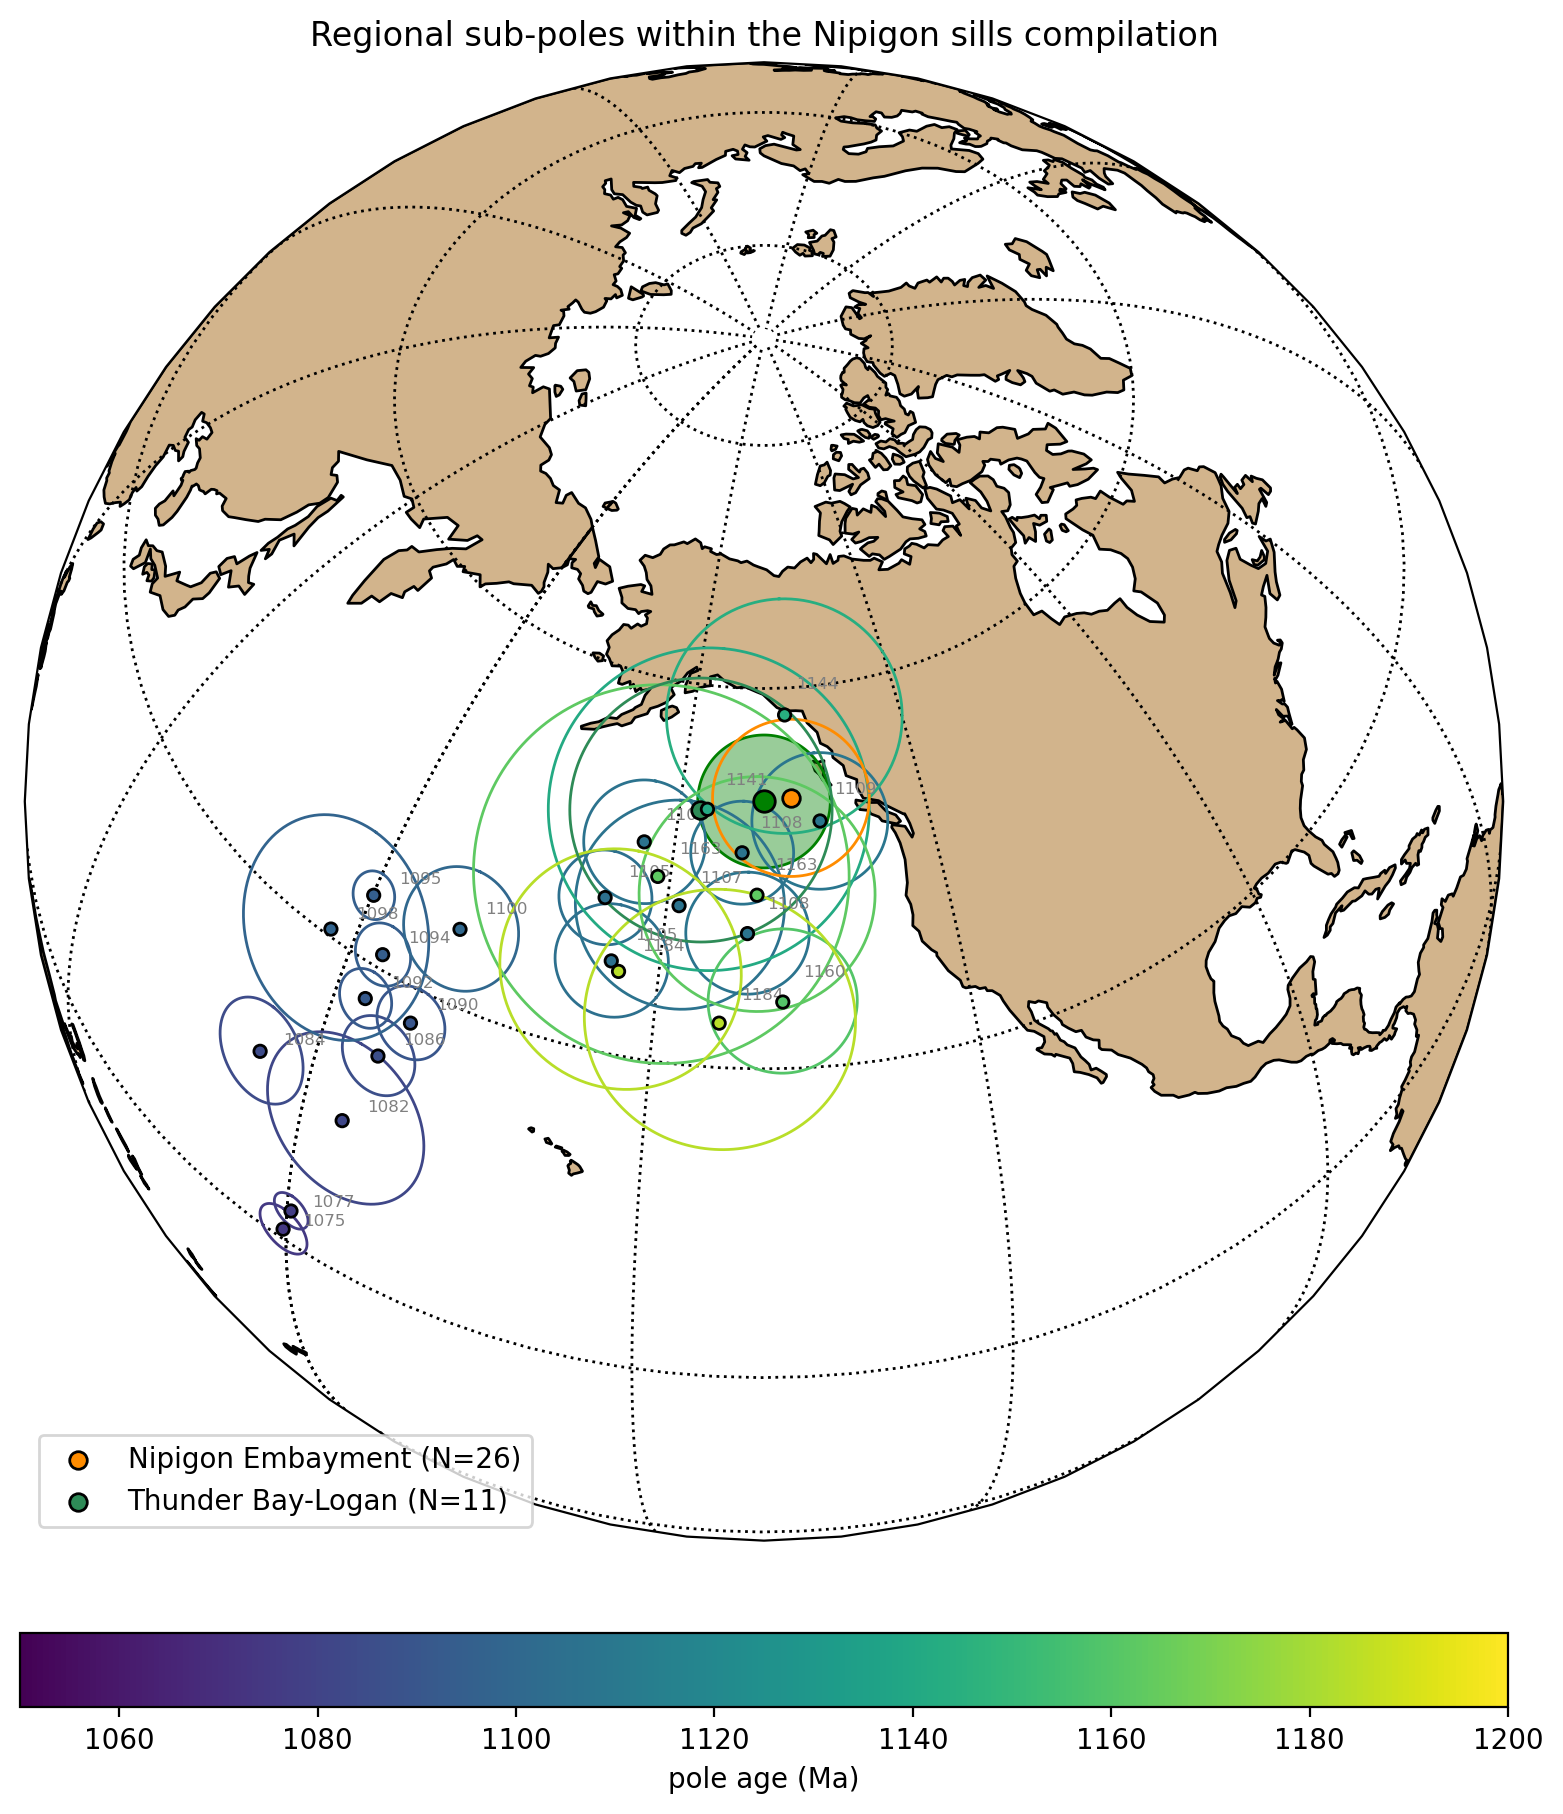

In [11]:
ax = pt.plot_apwp_context(pt.get_Laurentia_poles(), pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=1050, age_max=1200,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
for region, color in [('Nipigon Embayment', 'darkorange'), ('Thunder Bay-Logan', 'seagreen')]:
    p = region_results[region]['pole']
    ipmag.plot_pole(ax, p['dec'], p['inc'], p['alpha95'], color=color,
                    markersize=40, label=f'{region} (N={p["n"]})')
ax.legend(loc='lower left')
plt.title('Regional sub-poles within the Nipigon sills compilation')
plt.show()

The two regional means overlap within their confidence circles, so the compilation is
treated as a single population. The Thunder Bay-Logan mean is displaced to lower pole
longitude, in the direction of the younger part of the Keweenawan track; whether that
reflects a real age difference between the Mount McKay-area sills (1106.3 +/- 2.0 Ma;
Bleeker et al., 2020) and the Nipigon Embayment sills, or simply the lower precision of
that smaller group, is not resolved by these data.


## Comparison between studies

Agreement between studies that used very different laboratory methods over four decades
is a further check that the compiled directions record a single magnetization.


In [12]:
STUDIES = {'10.4095/100589': 'DuBois (1962)',
           '10.1139/e71-125': 'Robertson & Fahrig (1971)',
           '10.17741/bgsf/51.1-2.004': 'Pesonen (1979)',
           '10.1029/2003JB002581': 'Middleton et al. (2004)',
           '10.1016/j.precamres.2005.10.007': 'Borradaile & Middleton (2006)',
           'Piispa et al., in preparation': 'Piispa et al. (in prep.)'}

for doi, name in STUDIES.items():
    sub = units[units['citations'].str.contains(doi, regex=False)]
    if len(sub) < 3:
        print(f'{name:32s} N={len(sub):3d}  (too few units for a mean)')
        continue
    _, p = pt.compute_mean_pole(sub, unify_polarity=True)
    print(f'{name:32s} N={p["n"]:3d}  plat={p["inc"]:5.1f}  plon={p["dec"]:6.1f}  '
          f'A95={p["alpha95"]:5.1f}  K={p["k"]:5.1f}')

DuBois (1962)                    N= 13  plat= 54.8  plon= 220.7  A95=  8.4  K= 25.4
Robertson & Fahrig (1971)        N= 11  plat= 51.8  plon= 218.4  A95= 11.7  K= 16.2
Pesonen (1979)                   N= 10  plat= 47.7  plon= 225.6  A95= 11.6  K= 18.4
Middleton et al. (2004)          N=  9  plat= 52.4  plon= 218.8  A95= 10.5  K= 25.1
Borradaile & Middleton (2006)    N=  2  (too few units for a mean)
Piispa et al. (in prep.)         N=  1  (too few units for a mean)


## Are any sills still counted twice?

Each sill should contribute a single VGP. Two same-sill correlations beyond those
identified in the source compilation are established by the source publications and are
applied in the site table:

* **DuBois N29 (the sill at Red Rock) and N27-N28 (the sediment it baked).** DuBois's
  Table XIII places all three at one cliff above the CPR and CNR tracks at Red Rock, with
  N27-N28 "from sediment immediately below diabase sill" and N29 "from lower part of the
  sill". A sill and the sediment it baked record the same cooling event, so both join the
  Red Rock North unit.
* **Robertson and Fahrig S7 and DuBois's Mount Mackay sites.** S7 plots 0.33 km from the
  lower Mount McKay sill at Fort William, the exposure dated by Bleeker et al. (2020) at
  1106.3 +/- 2.0 Ma. DuBois obtained badly scattered directions there, attributed them to
  a superimposed random component and resorted to great-circle fits (his Table XV); S7
  (k = 92) is much the better determination of that sill.

A third candidate is **refuted**. Pesonen R47 and R49 carry identical coordinates and
identical notes ("North shore of Nipigon Bay, same sill as R&F S14&15?") in the source
compilation, which suggested they might be one sill. The Geological Survey of Finland
report version of Pesonen (1979) (Report 1942, Q 20/27.2/79/1) states that the 270 hand
samples came "from 18 reversed and 22 normal dikes and from 10 reversed sills", and its
Figure 1 plots R47 and R49 as two separate sill sites on the north shore of Nipigon Bay
with R49 slightly north of R47. Sites R40-R49 are ten distinct sills by Pesonen's own
count, so they are kept separate; the shared coordinates are a digitizing artifact to
correct in the source compilation.

Two candidates remain unresolved. Robertson and Fahrig (1971) describe none of their
sites, so their site positions here are digitized from that paper's Figure 1.

| Candidate | Basis | Status |
|---|---|---|
| Robertson and Fahrig S8 with DuBois N19-21 | 3.5 km apart on the Highway 11 scarp south of Orient Bay | needs the map |
| DuBois N16-18 with N9-11 (Doghead Mountain) | DuBois locates N16 "2 miles southwest of Ozone Station" and N9-N11 "just south of Ozone Station" | needs the map |

A structural caveat limits how far this can be pushed: the Logan sills are laterally
extensive sheets that transgress from one bedding plane to another (Robertson and Fahrig,
1971), so exposures tens of kilometres apart may belong to one cooling unit. The source
compilation already merges Pesonen R45 into the Terry Fox unit on that basis: Pesonen's
Figure 1 places R45 near Pass Lake at the neck of the Sibley Peninsula, ~27 km northeast
of the Current River / Terry Fox exposure sampled by DuBois, Robertson and Fahrig and
Middleton et al., so the merge asserts that one sheet is continuous over that distance.
Applied consistently, such map-based correlation would likely reduce the unit count
further; N = 37 is therefore an upper bound on the number of independent cooling units.


In [13]:
CANDIDATE_MERGES = {'S8': 'N19-21', 'N16-18': 'Doghead Mountain'}


def pole_with_merges(merges=(), drop=()):
    """Recomputes the pole after further merging or dropping named units.

    Units named in ``merges`` are folded into their target unit by taking the
    Fisher mean of the two units' VGPs before the pole is computed, so that a
    sill counted twice contributes a single VGP.

    Args:
        merges (dict or tuple): Mapping of unit name to the unit it merges into.
        drop (iterable): Unit names to exclude entirely.

    Returns:
        dict: Fisher mean pole from ``ipmag.fisher_mean``.
    """
    u = units[~units['site'].isin(drop)].copy()
    u['merged_site'] = u['site'].map(dict(merges)).fillna(u['site'])
    rows = []
    for _, g in u.groupby('merged_site'):
        m = ipmag.fisher_mean(dec=list(g['vgp_lon']), inc=list(g['vgp_lat']))
        rows.append((m['dec'], m['inc']))
    return ipmag.fisher_mean(dec=[r[0] for r in rows], inc=[r[1] for r in rows])


def row(label, **kw):
    p = pole_with_merges(**kw)
    return {'selection': label, 'N': p['n'], 'plat': round(p['inc'], 1),
            'plon': round(p['dec'], 1), 'A95': round(p['alpha95'], 1),
            'K': round(p['k'], 1)}

same_sill = pd.DataFrame([
    row('preferred (applied merges only)'),
    row('+ S8 into N19-21', merges={'S8': 'N19-21'}),
    row('+ N16-18 into Doghead Mountain', merges={'N16-18': 'Doghead Mountain'}),
    row('+ both candidate merges', merges=CANDIDATE_MERGES),
    row('+ both merges, refuted R49 merge applied anyway', merges=dict(CANDIDATE_MERGES, **{'R49': 'Kama Hill'})),
])
same_sill

,selection,N,plat,plon,A95,K
0,preferred (applied merges only),37,51.2,220.3,5.2,21.8
1,+ S8 into N19-21,36,51.2,220.2,5.3,21.3
2,+ N16-18 into Doghead Mountain,36,51.0,220.5,5.3,21.6
3,+ both candidate merges,35,51.0,220.4,5.4,21.0
4,"+ both merges, refuted R49 merge applied anyway",34,51.5,219.7,5.4,21.8


The pole moves by less than half a degree under any combination of the
unresolved merges, so the outcome of the map check will not change the result; what it
changes is the honest value of N and hence A95. K rises as duplicated determinations are
removed, which is the expected signature of collapsing non-independent readings of the
same cooling event.


## Sensitivity of the pole to compilation choices

Several units carry caveats from the source studies. Robertson and Fahrig's S5 and S6
("Colville Lake") may belong to the younger *ca.* 1100.8 Ma McIntyre diabase; the Seagull
Intrusion is dated at 1112 +/- 2.4 Ma (Hart and Whaley, 2005, as reported by Borradaile
and Middleton, 2006) and so may predate the sills; and several units have very poorly
determined mean directions (DuBois's Mount McKay and P8m results, for which he invoked
great-circle fits and noted possible lightning remagnetization, and Middleton's Hele 2 and
Havoc sites, whose thermal and low-temperature treatments give discordant directions).


In [14]:
def summarize(sub, label):
    _, p = pt.compute_mean_pole(sub, unify_polarity=True)
    return {'selection': label, 'N': p['n'], 'plat': round(p['inc'], 1),
            'plon': round(p['dec'], 1), 'A95': round(p['alpha95'], 1),
            'K': round(p['k'], 1)}

sensitivity = pd.DataFrame([
    summarize(units, 'all units (preferred)'),
    summarize(units[units['site'] != 'Colville Lake'], 'drop Colville Lake (possible McIntyre diabase)'),
    summarize(units[units['site'] != 'Seagull Intrusion'], 'drop Seagull Intrusion (ca. 1112 Ma)'),
    summarize(units[units['dir_alpha95'] <= 30], 'drop units with mean-direction alpha95 > 30 deg'),
    summarize(units[units['dir_alpha95'] <= 20], 'drop units with mean-direction alpha95 > 20 deg'),
    summarize(units[units['site'] != 'P8m'], 'drop P8m (2 discordant samples, alpha95 138 deg)'),
    summarize(units[~units['site'].isin(['P8m', 'N31m'])], 'drop P8m and N31m (N31m is a dyke cutting the Sleeping Giant sill)'),
    summarize(units[units['location'] == 'Nipigon Embayment'], 'Nipigon Embayment only'),
    summarize(units[units['location'] == 'Thunder Bay-Logan'], 'Thunder Bay-Logan only'),
])
sensitivity

,selection,N,plat,plon,A95,K
0,all units (preferred),37,51.2,220.3,5.2,21.8
1,drop Colville Lake (possible McIntyre diabase),36,51.9,219.4,5.0,23.4
2,drop Seagull Intrusion (ca. 1112 Ma),36,51.5,219.8,5.3,21.6
3,drop units with mean-direction alpha95 > 30 deg,29,50.4,221.1,5.9,21.7
4,drop units with mean-direction alpha95 > 20 deg,25,48.1,220.5,5.6,27.6
5,"drop P8m (2 discordant samples, alpha95 138 deg)",36,51.3,218.8,5.0,24.0
6,drop P8m and N31m (N31m is a dyke cutting the ...,35,51.2,219.2,5.1,23.6
7,Nipigon Embayment only,26,51.4,223.7,6.1,22.6
8,Thunder Bay-Logan only,11,50.3,212.5,10.3,20.7


The pole position is stable at the few-degree level across all of these choices, well
within the A95 of the preferred mean, so no unit is excluded on these grounds. Note that
for units built by merging determinations from several studies the tabulated alpha95
describes the scatter *between* those determinations rather than within a site, so the
alpha95 filters preferentially remove well-replicated sills and are a conservative rather
than a sharpening test.


## Statistical assessment (Meert et al., 2020; R2)

In [15]:
_ = pt.assess_R2(units, pole_mean)

R2 assessment (Meert et al., 2020):
  (a) two demag methods (AF + thermal)  [advisory, from method_codes]: yes
  (b) PCA / great-circle component analysis  [advisory, from method_codes]: yes
      note: method codes are inconsistently applied; confirm (a)/(b) against the source publication.
  (c) adequate PSV sampling [scored]:
        N = 371 samples (>= 25): PASS
        K = 21.8 (10-70): PASS
        B = 37 sites (>= 8): PASS
        min 2 samples/site [advisory only, not a gate; Sapienza et al., 2023]
        A95 = 5.2 in Deenen envelope [2.8, 8.4]: PASS
  => R2 (from sub-criterion c) = 1


## Position within the Laurentia apparent polar wander path

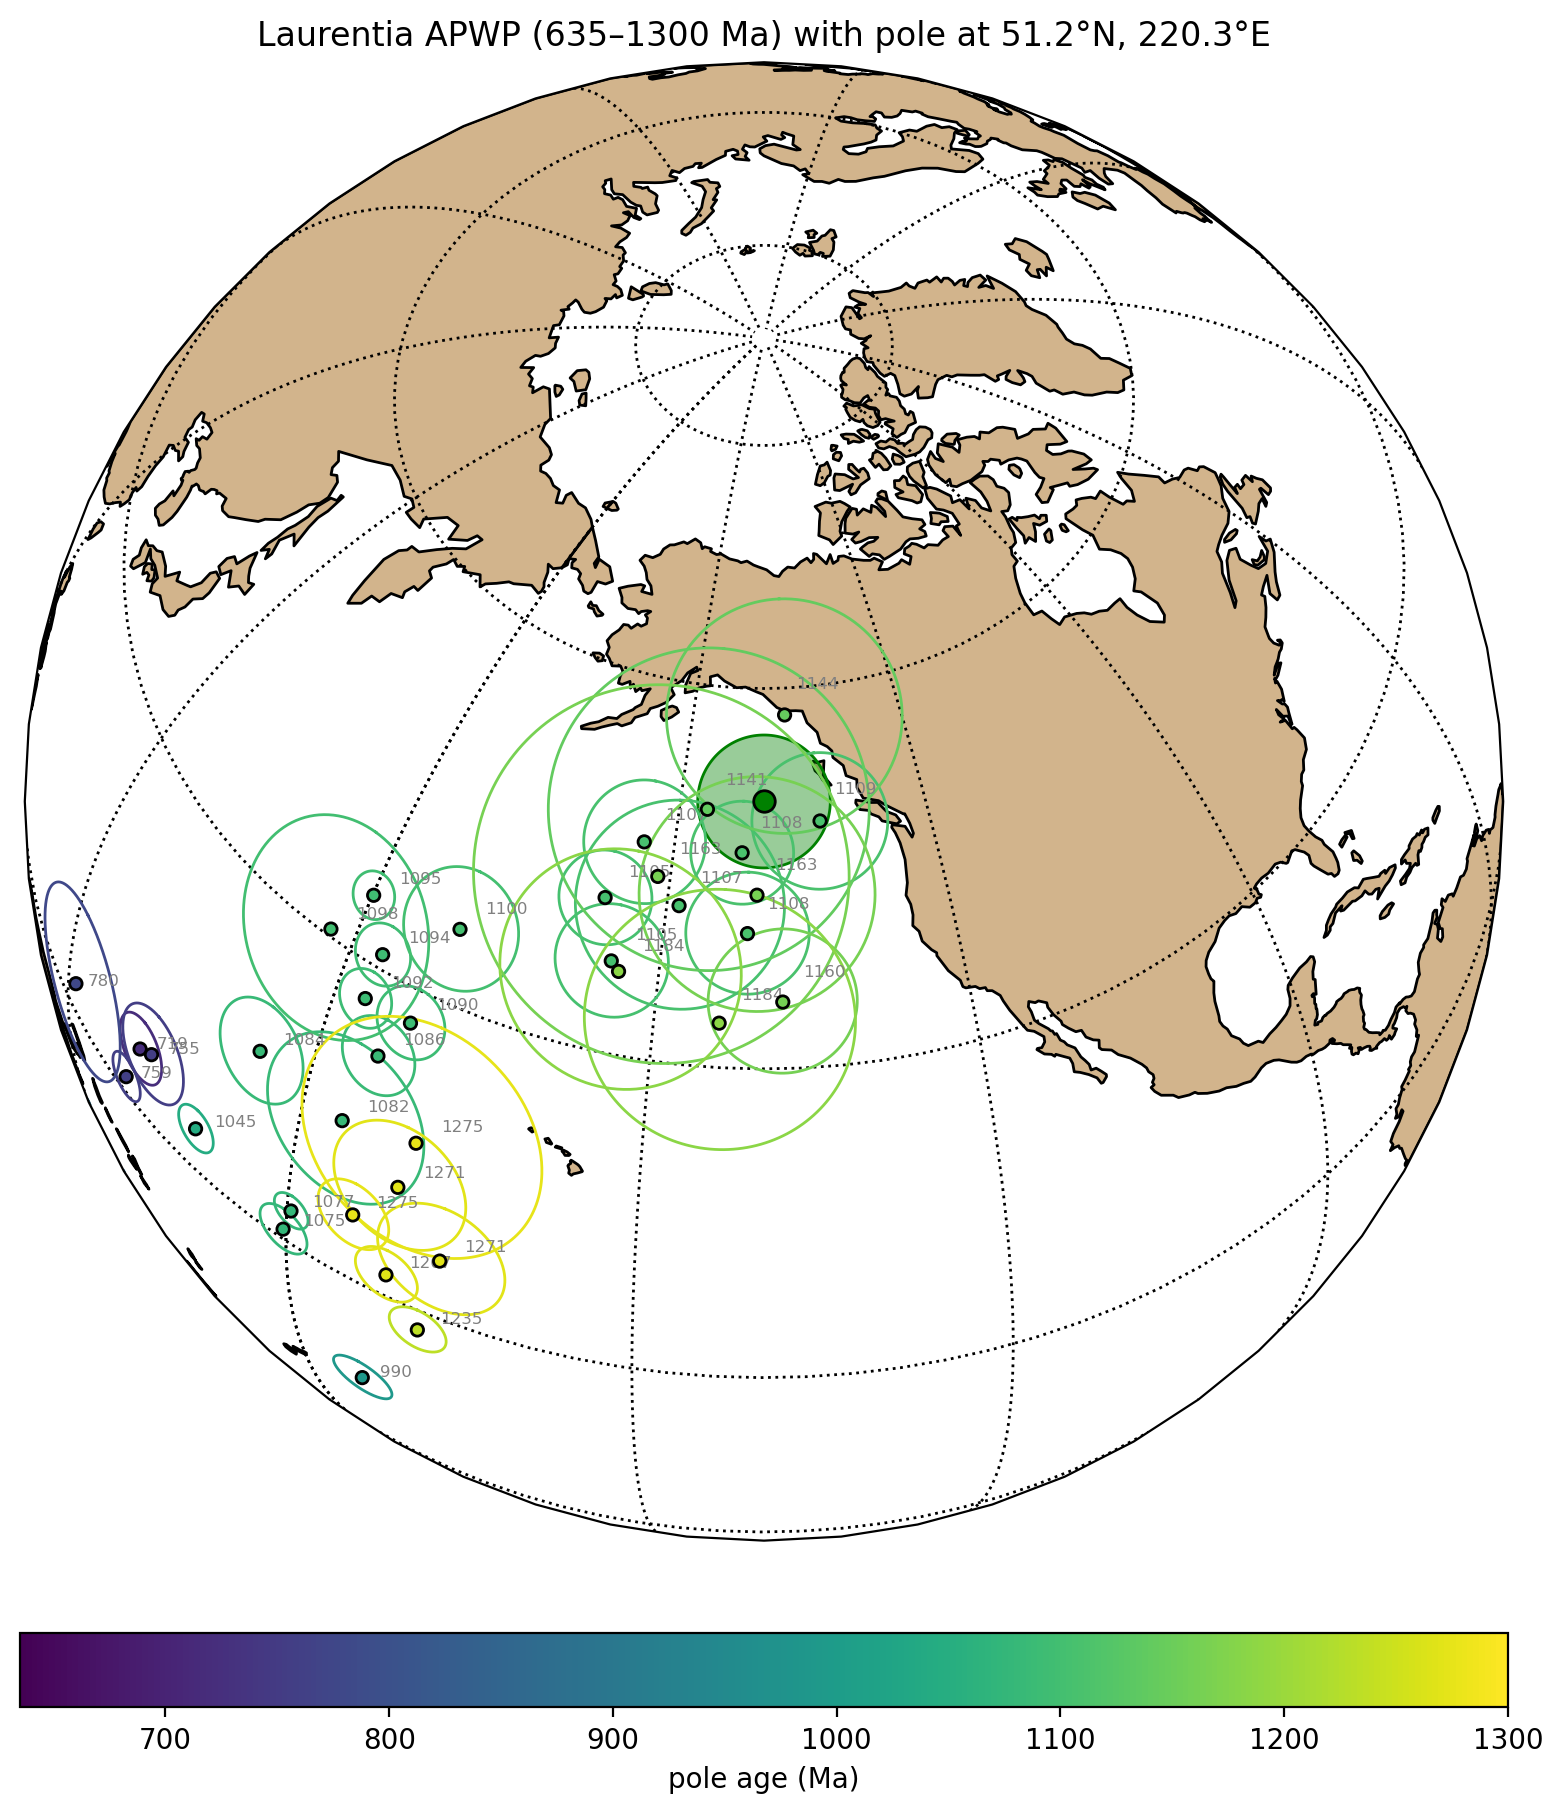

In [16]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1300,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

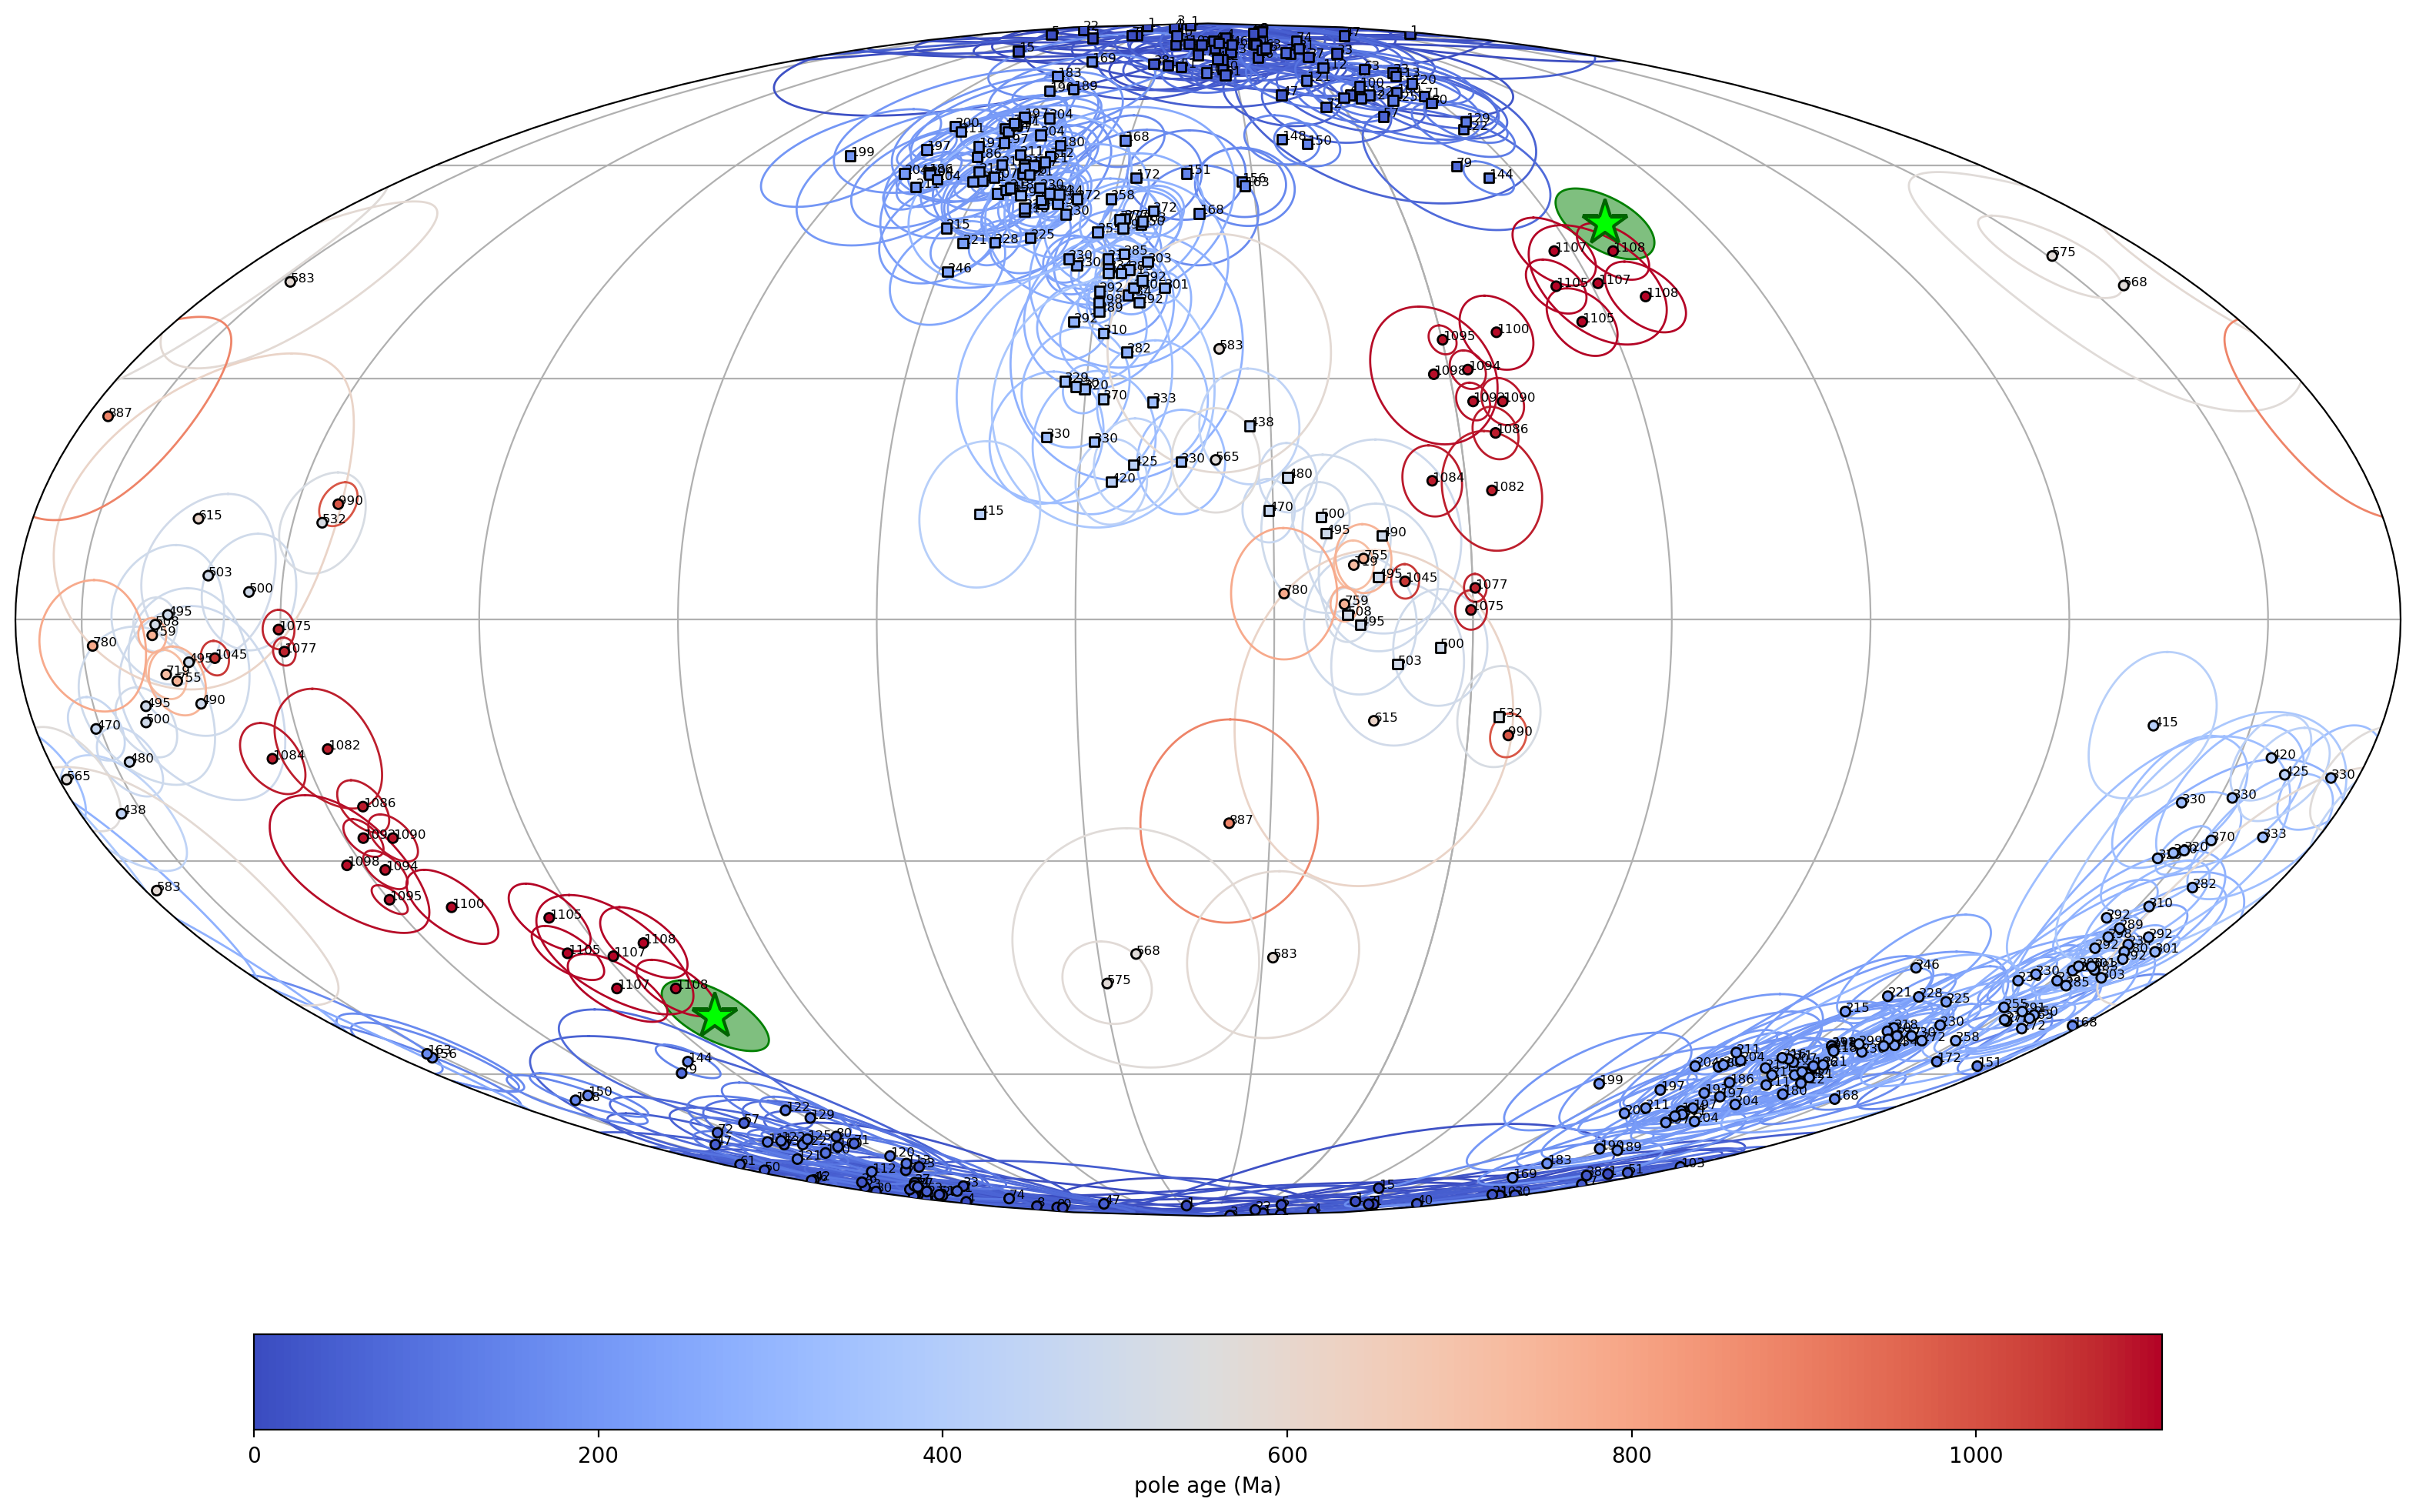

In [17]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
# 'MEAN Nipigon sills and lavas' is this unit's ROCKNAME in Laurentia_poles.csv,
# so naming it here excludes the superseded entry from the younger-pole comparison
_ = pt.plot_pole_overlap('MEAN Nipigon sills and lavas', Laurentia_stricto_poles,
                         pt.Torsvik2012_Laurentia,
                         pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                         pole_A95=pole_mean['alpha95'], pole_age=1108)
plt.show()

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | Nipigon sills 1108.2 ± 0.9 Ma (recalculated from Davis & Sutcliffe, 1985); Logan Sill at Mount McKay 1106.3 ± 2.0 Ma and Inspiration sill 1105.5 ± 3.0 Ma (Bleeker et al., 2020). |
| 2 | Techniques and statistical analysis | **1** | See the R2 assessment above: N = 37 independent units, K = 21.8 and A95 = 5.2° within the Deenen et al. (2011) envelope, and the unit VGPs are consistent with a Fisher distribution. Stepwise AF and thermal demagnetization with PCA in Pesonen (1979), Middleton et al. (2004) and Borradaile & Middleton (2006); DuBois (1962) and Robertson & Fahrig (1971) used blanket cleaning only. Individual determinations are of mixed quality, but the pole is stable to the exclusion of the poorest units and the four study means agree within uncertainty. |
| 3 | Magnetic mineralogy characterized | **1** | Magnetite (with ilmenite intergrowths and minor pyrrhotite) identified by Robertson & Fahrig (1971); rock-magnetic and opaque-mineral characterization in Middleton et al. (2004) and Borradaile & Middleton (2006). |
| 4 | Field tests constrain age of magnetization | **c** | Positive inverse baked-contact tests: baked Sibley Group and Rove Formation adjacent to the reversed sills carry the sill direction while unbaked host rock does not (Pesonen, 1979, Table 4). |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous Superior craton; subhorizontal sills, geographic coordinates. |
| 6 | Presence of reversals | **0** | Single (reverse) polarity. |
| 7 | No resemblance to younger poles | **1** | On the Keweenawan track and distinct from the younger normal-polarity Midcontinent Rift poles. |
| | Total | **6/7** | Grade A |


## Nordic workshop summary

The pole is exported in the Nordic compilation format. In contrast to the previous entry,
which carried the Lulea Working Group grand mean with sentinel values for the site and
sample counts and the direction precision, the exported statistics are now the recomputed
site-level quantities.

| | This study (unit VGPs) | Previous Nordic compilation |
|---|---|---|
| Component | Nipigon (Logan) sills, ChRM | MEAN Nipigon sills and lavas |
| N (units / sites) | 37 | 86 |
| Pole lat (°N) | see below | 47.2 |
| Pole lon (°E) | see below | 217.8 |
| A95 (°) | see below | 4.0 |


In [18]:
nipigon_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Nipigon sills',
    sites=units,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=STUDY_LON,
    study_lat=STUDY_LAT,
    component_comment=('Single reverse-polarity ChRM of the Nipigon (Logan) sills and '
                       'related intrusions; Fisher mean of independent unit VGPs '
                       'recompiled from DuBois (1962), Robertson & Fahrig (1971), '
                       'Pesonen (1979), Middleton et al. (2004), Borradaile & Middleton '
                       '(2006) and Piispa et al. (in prep.)'),
    tests='c+ (positive inverse baked-contact test on Sibley Group and Rove Formation; Pesonen, 1979)',
    gpmdb_number='',
    magic_id='',
    percent_reversed=100,
    demag_code=3,
    R1=1, R2=1, R3=1, R4='c', R5=1, R6=0, R7=1, Grade='A', Grade_E21='A',
    nominal_age=1108, lomagage=1106, himagage=1110,
    REF_method=('The Nipigon (Logan) sills cluster in age near 1105-1109 Ma. The Nipigon '
                'sills are dated at 1108.2 +/- 0.9 Ma (zircon upper intercept, '
                'recalculated from the data of Davis and Sutcliffe, 1985), and Bleeker et '
                'al. (2020) report new high-precision U-Pb dates of 1106.3 +/- 2.0 Ma for '
                'the main Logan Sill at Mount McKay and 1105.5 +/- 3.0 Ma for the '
                'Inspiration sill. The pole is assigned an age of 1108 +/- 2 Ma. The older '
                'Heaman et al. (2007) baddeleyite dates are imprecise and superseded and '
                'are not used here.'),
    POLE_AUTHORS=('Iloranta, E. J. compilation of DuBois (1962), Robertson & Fahrig (1971), '
                  'Pesonen (1979), Middleton et al. (2004), Borradaile & Middleton (2006) '
                  'and Piispa et al. (in prep.)'),
    YEAR=2026,
    JOURNAL='',
    VOLUME='',
    VPAGES='',
    TITLE='Nipigon (Logan) sills ca. 1108 Ma pole, recomputed from site-level data',
    COMMENT=('Replaces the Lulea Working Group (2009) eight-unit grand mean carried in '
             'Evans et al. (2021) (47.2 N / 217.8 E, A95 4.0, B = 86) with a pole '
             'recomputed from published site means. Repeat determinations of the same '
             'sill are averaged into independent cooling units in two stages: the 15 '
             'entries of Middleton et al. (2004) Table 1 collapse to their 9 sampling '
             'localities, and sills sampled by more than one study are merged. Pillar '
             'Lake Lava, three normal-polarity Middleton et al. (2004) entries '
             'interpreted as incompletely removed overprints, and two results flagged as '
             'excluded in the source compilation are omitted. Geographic coordinates '
             '(intrusive, no tilt correction).')
)
pt.save_nordic_summary(nipigon_summary, '1108_Nipigon')
nipigon_summary

,Terrane,ROCKNAME,GPMDB RESULT#,MAGIC #,COMPONENT,TESTS,TILT,SLAT,SLONG,B,...,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment,Lithology
0,Laurentia,Nipigon sills,,,Single reverse-polarity ChRM of the Nipigon (L...,c+ (positive inverse baked-contact test on Sib...,0,48.89,271.26,37,...,The Nipigon (Logan) sills cluster in age near ...,Nipigon sills,"Iloranta, E. J. compilation of DuBois (1962), ...",2026,,,,"Nipigon (Logan) sills ca. 1108 Ma pole, recomp...",Replaces the Lulea Working Group (2009) eight-...,Diabase; Intrusives; Gabbro
